# Figures

Generates Figs. 2 to 7 of *Scoping review of governance, privacy, and design in AI-supported conversational agents for perinatal mental health*. Fig. 1 (PRISMA-ScR flow diagram) is produced separately.

| Section | Article figure | Output files |
|---|---|---|
| Fig. 2 | Geographic distribution of perinatal CAs (30 unique systems) | `fig2_geography.png/.pdf` |
| Fig. 3 | Publications over time by model class (N = 35) | `fig3_publications_by_model_class.png/.pdf` |
| Fig. 4 | Clinical scope, functions and therapeutic foundations | `fig4_clinical_scope.png/.pdf` |
| Fig. 5 | Governance maturity by model class and crisis-escalation tier | `fig5_gms_by_model_class.png/.pdf` |
| Fig. 6 | Governance Maturity Profile across the six GMS dimensions | `fig6_gms_profile.png/.pdf` |
| Fig. 7 | Governance reporting by model class | `fig7_governance_reporting.png/.pdf` |

Figs. 3, 5, 6 and 7 are drawn directly from `data/`. Figs. 2 and 4 use system-level and clinical-scope counts entered below; their source rows are in Supplementary Data 1 (sheets 1, 4 and 10).

Run all cells from the `figures/` folder. Figures are written to `figures/output/`.

In [9]:
from collections import Counter
from pathlib import Path

import geopandas as gpd
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
DATA = ROOT / "data"
OUT = ROOT / "figures" / "output"
OUT.mkdir(parents=True, exist_ok=True)

# keep_default_na=False: the crisis tier "None" is a category, not missing data
gms = pd.read_csv(DATA / "gms_scores.csv", keep_default_na=False).sort_values("study_id")
elements = pd.read_csv(DATA / "governance_elements.csv")
assert len(gms) == 35 and gms["gms_total"].sum() == 262


def save(fig, name, dpi=300):
    """Save a figure as PNG and PDF in figures/output/."""
    for ext in ("png", "pdf"):
        fig.savefig(OUT / f"{name}.{ext}", dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"saved {name}.png / .pdf")

## Fig. 2 | Geographic distribution of perinatal CAs

saved fig2_geography.png / .pdf


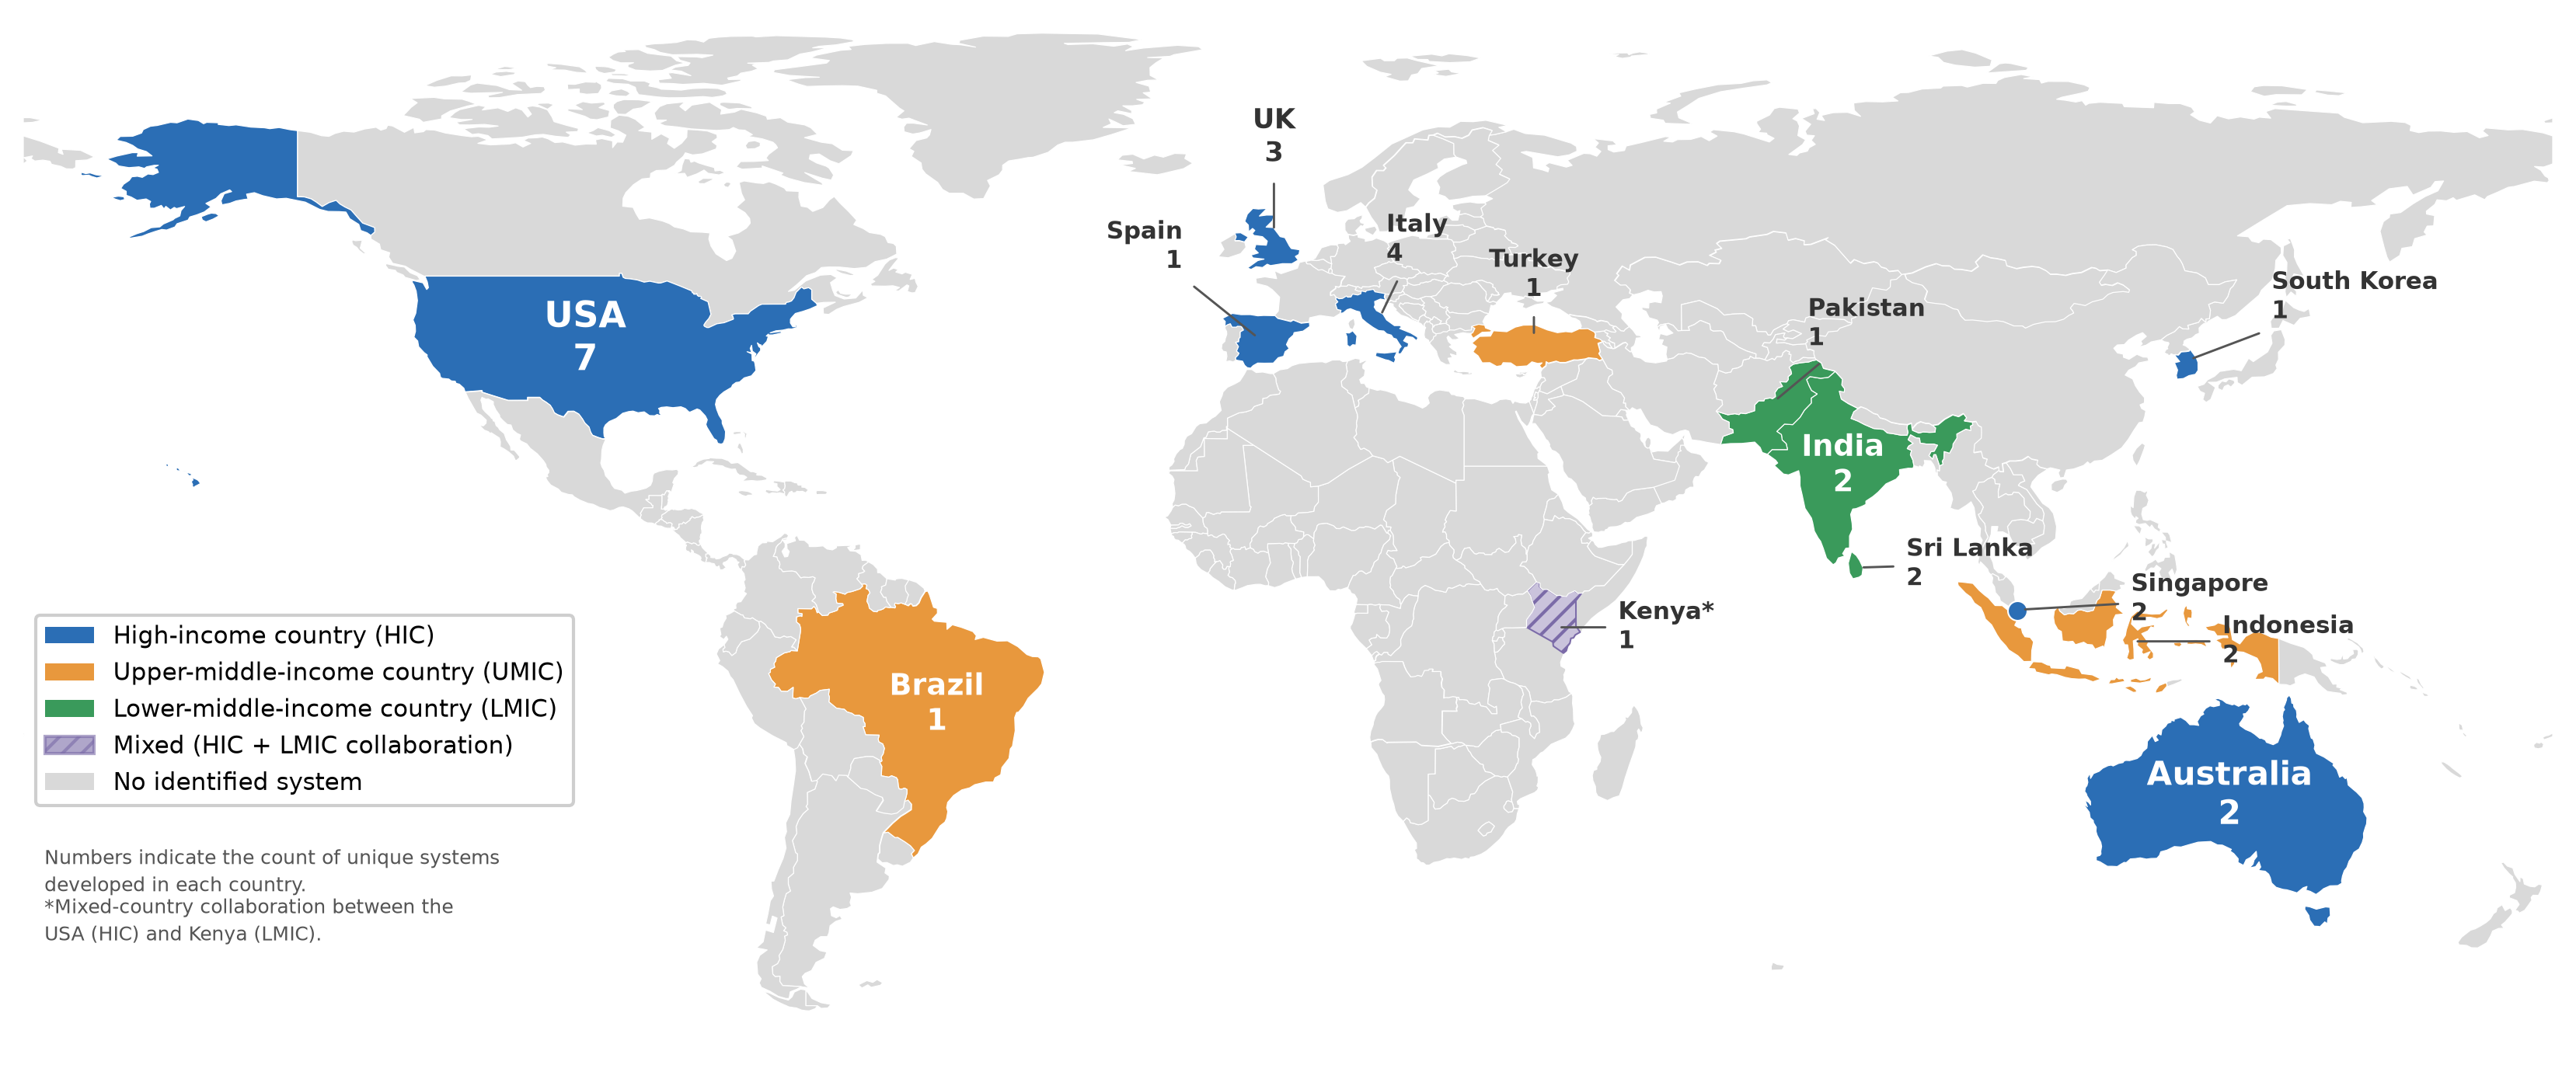

In [10]:
"""
Fig. 2 | Geographic distribution of perinatal mental health CA development
(unique systems, n = 30), coloured by World Bank income group.
"""

# ---- LOAD WORLD ----
world = gpd.read_file(ROOT / "figures" / "countries.geojson")

# ---- DATA ----
country_data = {
    "United States of America": (7, "HIC"),
    "United Kingdom":           (3, "HIC"),
    "Italy":                    (4, "HIC"),
    "Spain":                    (1, "HIC"),
    "Australia":                (2, "HIC"),
    "South Korea":              (1, "HIC"),
    "Turkey":                   (1, "UMIC"),
    "Brazil":                   (1, "UMIC"),
    "Indonesia":                (2, "UMIC"),
    "India":                    (2, "LMIC"),
    "Sri Lanka":                (2, "LMIC"),
    "Pakistan":                 (1, "LMIC"),
    "Kenya":                    (1, "Mixed"),
}
# Singapore not in 110m shapefile — handle as point marker
singapore = (2, "HIC", 103.8, 1.35)

colors = {
    "HIC":   "#2B6EB5",
    "UMIC":  "#E8983D",
    "LMIC":  "#3A9A5B",
    "Mixed": "#7B6BA8",
    "none":  "#D9D9D9",
}

# Assign colors
world["color"] = colors["none"]
world["income"] = "none"
for _, row in world.iterrows():
    name = row["ADMIN"]
    if name in country_data:
        _, income = country_data[name]
        world.loc[world["ADMIN"] == name, "color"] = colors[income]
        world.loc[world["ADMIN"] == name, "income"] = income

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(14, 7.5), dpi=300, facecolor="white")
ax.set_facecolor("white")

# Draw all countries
for _, row in world.iterrows():
    income = row["income"]
    if income == "Mixed":
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color=colors["Mixed"], edgecolor="white",
                                           linewidth=0.3, alpha=0.4)
        gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor="none", edgecolor=colors["Mixed"],
                                           linewidth=0.5, hatch="////")
    else:
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color=row["color"], edgecolor="white", linewidth=0.3)

# Singapore as colored circle (too small for polygon at 110m)
ax.plot(singapore[2], singapore[3], "o", color=colors["HIC"], markersize=6,
        markeredgecolor="white", markeredgewidth=0.5, zorder=10)

# ---- LABELS ----
label_config = [
    # (lon_text, lat_text, text, fontsize, ha, va, arrow_to_lon, arrow_to_lat)
    # All small countries get sharp straight leader lines
    (-2,   64,   "UK\n3",            8.5, "center", "bottom", -2, 55),
    (-15,  49,   "Spain\n1",         7.5, "right", "bottom", -4, 40),
    (14,   50,   "Italy\n4",         7.5, "left", "bottom", 13, 43),
    (35,   45,   "Turkey\n1",        7.5, "center", "bottom", 35, 40),
    (140,  46,   "South Korea\n1",   7.5, "left", "center", 128, 37),
    (120,   3,   "Singapore\n2",     7.5, "left", "center", 104, 1.5),
    (133,  -3,   "Indonesia\n2",     7.5, "left", "center", 120, -3),
    (88,    8,   "Sri Lanka\n2",     7.5, "left", "center", 81, 7.5),
    (74,   38,   "Pakistan\n1",      7.5, "left", "bottom", 69, 31),
    (47,   -1,   "Kenya*\n1",        7.5, "left", "center", 38, -1),
]

for item in label_config:
    tx, ty, text, fs, ha, va, ax2, ay2 = item
    if ax2 is not None:
        # Leader line
        ax.annotate(text, xy=(ax2, ay2), xytext=(tx, ty),
                    fontsize=fs, fontweight="bold", color="#333333",
                    ha=ha, va=va,
                    arrowprops=dict(arrowstyle="-", color="#555555", lw=0.7,
                                   connectionstyle="arc3,rad=0.0"),
                    zorder=15)
    else:
        ax.text(tx, ty, text, fontsize=fs, fontweight="bold", color="#333333",
                ha=ha, va=va, zorder=15)

# White text for large colored countries
for tx, ty, text, fs in [(-100, 40, "USA\n7", 11), (134, -25, "Australia\n2", 10),
                          (-50, -12, "Brazil\n1", 9), (79, 22, "India\n2", 9)]:
    ax.text(tx, ty, text, fontsize=fs, fontweight="bold", color="white",
            ha="center", va="center", zorder=16)


# ---- AXES ----
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_aspect("equal")
ax.axis("off")


# ---- LEGEND ----
legend_items = [
    mpatches.Patch(facecolor=colors["HIC"], edgecolor="none", label="High-income country (HIC)"),
    mpatches.Patch(facecolor=colors["UMIC"], edgecolor="none", label="Upper-middle-income country (UMIC)"),
    mpatches.Patch(facecolor=colors["LMIC"], edgecolor="none", label="Lower-middle-income country (LMIC)"),
    mpatches.Patch(facecolor=colors["Mixed"], edgecolor=colors["Mixed"],
                   label="Mixed (HIC + LMIC collaboration)", hatch="////", alpha=0.6),
    mpatches.Patch(facecolor=colors["none"], edgecolor="none", label="No identified system"),
]
leg = ax.legend(handles=legend_items, loc="lower left", fontsize=7.5,
                frameon=True, framealpha=0.95, edgecolor="#CCCCCC",
                bbox_to_anchor=(0.0, 0.22))

# Footnotes aligned directly under legend
ax.text(-177, -32,
        "Numbers indicate the count of unique systems\ndeveloped in each country.",
        fontsize=6, color="#555555", va="top", linespacing=1.4)
ax.text(-177, -39,
        "*Mixed-country collaboration between the\nUSA (HIC) and Kenya (LMIC).",
        fontsize=6, color="#555555", va="top", linespacing=1.4)


save(fig, "fig2_geography")
plt.show()

## Fig. 3 | Publications over time by model class

saved fig3_publications_by_model_class.png / .pdf


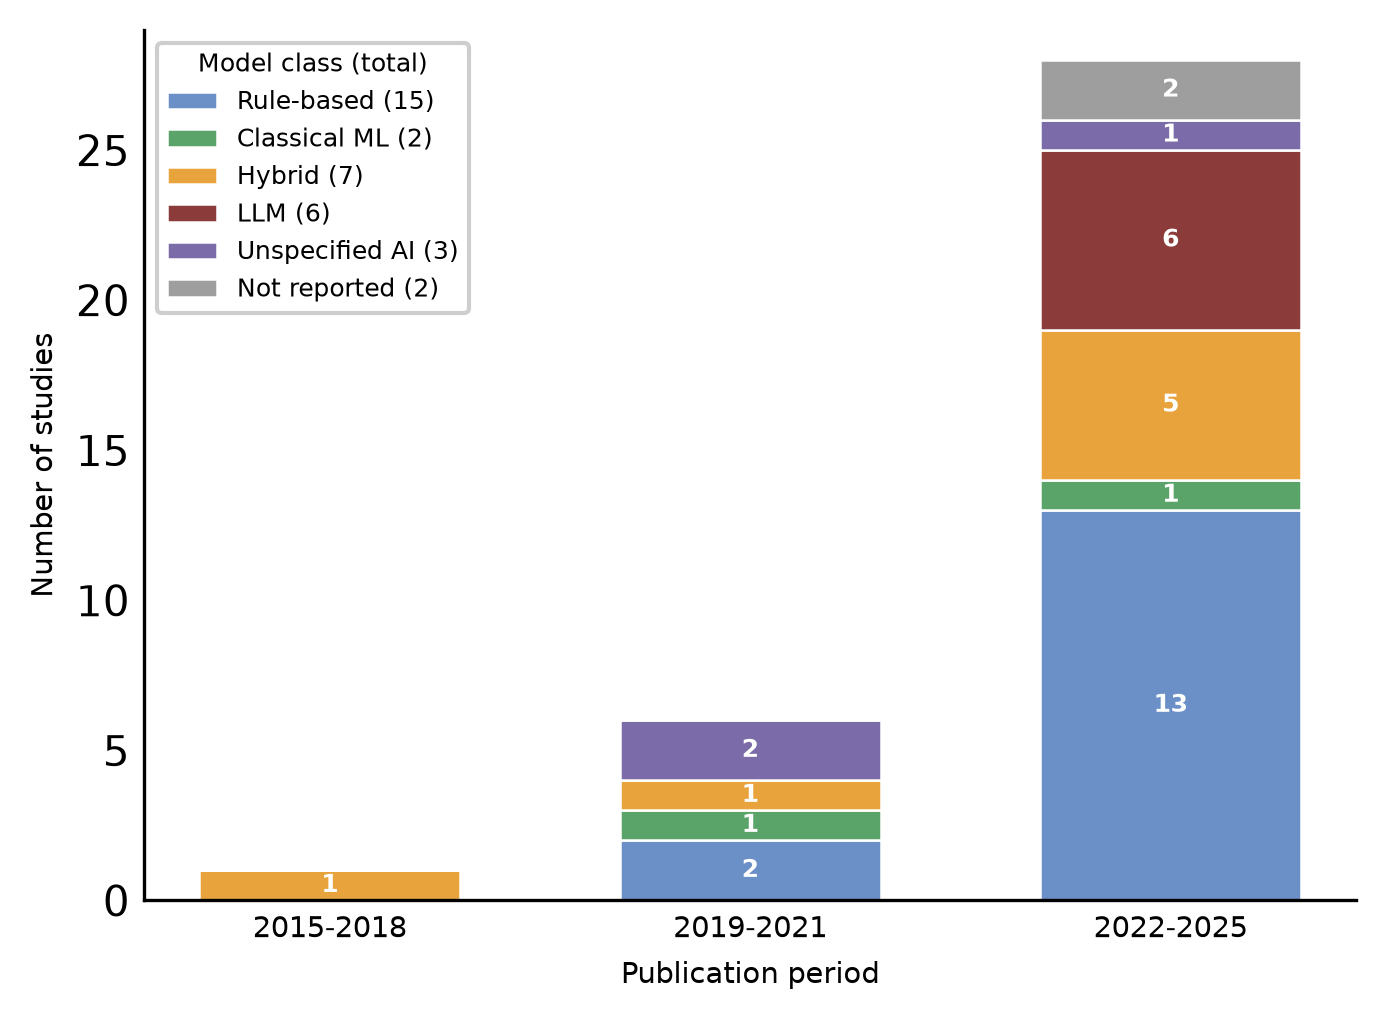

In [11]:
"""
Fig. 3 | Publications over time by model class (N = 35 studies)
Stacked bar chart with non-overlapping publication periods.
"""

# ---- DATA: model class and publication period for each study ----
def period(year):
    return "a" if year <= 2018 else ("b" if year <= 2021 else "c")

studies = {r.study_id: (r.model_class_analytic, period(r.publication_year))
           for r in gms.itertuples()}

# ---- CONFIGURATION ----
periods = ["a", "b", "c"]
period_labels = ["2015-2018", "2019-2021", "2022-2025"]
classes = ["Rule-based", "Classical ML", "Hybrid", "LLM", "Unspecified AI", "Not reported"]
colors = {
    "Rule-based":      "#6B8FC7",
    "Classical ML":    "#5AA469",
    "Hybrid":          "#E8A33D",
    "LLM":             "#8C3B3B",
    "Unspecified AI":  "#7B6BA8",
    "Not reported":    "#9E9E9E",
}

# ---- COUNT MATRIX ----
counts = {c: [0, 0, 0] for c in classes}
for sid, (cls, period) in studies.items():
    counts[cls][periods.index(period)] += 1

# Verify totals
totals = {c: sum(counts[c]) for c in classes}
assert sum(totals.values()) == 35, f"Total studies = {sum(totals.values())}, expected 35"

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(4.72, 3.5), dpi=300)

x = np.arange(3)
bar_width = 0.62
bottom = np.zeros(3)

for cls in classes:
    vals = np.array(counts[cls])
    ax.bar(
        x, vals, bottom=bottom, width=bar_width,
        color=colors[cls],
        label=f"{cls} ({totals[cls]})",
        edgecolor="white", linewidth=0.6,
    )
    # Value labels inside each segment
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(
                xi, b + v / 2, str(int(v)),
                ha="center", va="center",
                fontsize=6, color="white", fontweight="bold",
            )
    bottom += vals

# Axes
ax.set_xticks(x)
ax.set_xticklabels(period_labels, fontsize=7)
ax.set_ylabel("Number of studies", fontsize=7)
ax.set_xlabel("Publication period", fontsize=7)
ax.set_ylim(0, 29)
ax.set_yticks(range(0, 30, 5))


# Spines
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)

# Legend
ax.legend(
    fontsize=6, loc="upper left",
    frameon=True, framealpha=0.95,
    title="Model class (total)", title_fontsize=6,
)

plt.tight_layout()
save(fig, "fig3_publications_by_model_class")
plt.show()

## Fig. 4 | Clinical scope, functions and therapeutic foundations

saved fig4_clinical_scope.png / .pdf


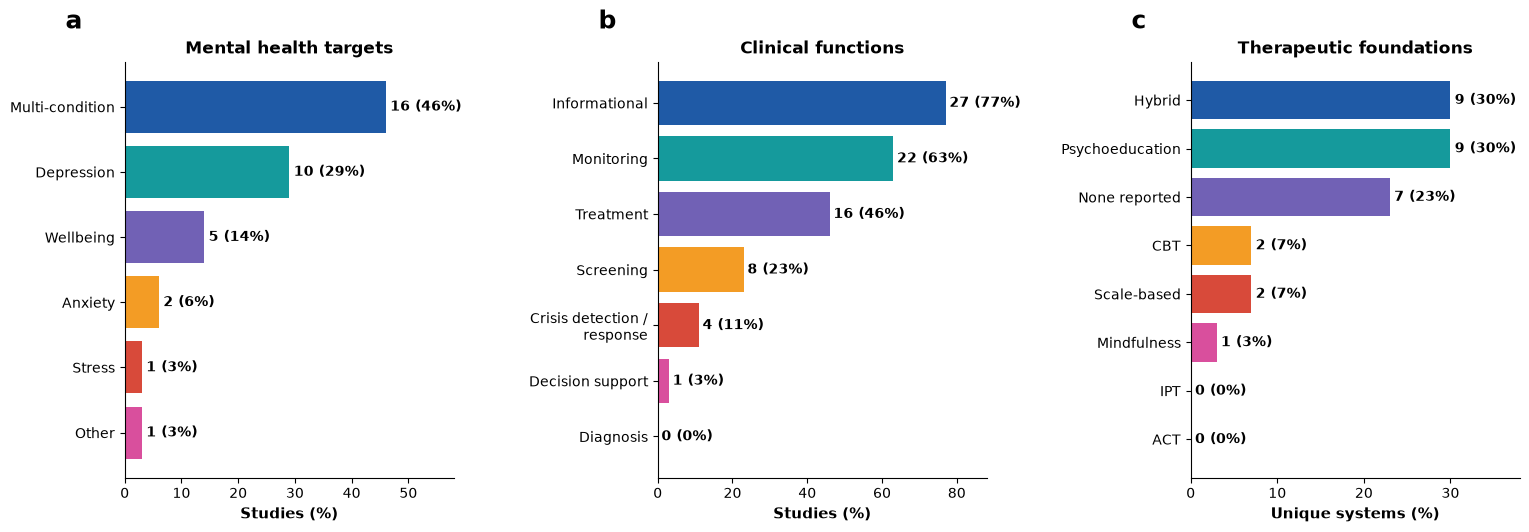

In [12]:
"""
Fig. 4 | Clinical scope, functions and therapeutic foundations.
Counts from Supplementary Data 1 (sheet 10, codebook dataset).
"""

# =========================
# DATA
# =========================

# Panel a: Mental health targets
# Mutually exclusive categories, n = 35 studies
target_labels = [
    "Multi-condition",
    "Depression",
    "Wellbeing",
    "Anxiety",
    "Stress",
    "Other"
]

target_counts = [16, 10, 5, 2, 1, 1]
target_percent = [46, 29, 14, 6, 3, 3]


# Panel b: Clinical functions
# Non-mutually exclusive categories, n = 35 studies
clinical_labels = [
    "Informational",
    "Monitoring",
    "Treatment",
    "Screening",
    "Crisis detection /\nresponse",
    "Decision support",
    "Diagnosis"
]

clinical_counts = [27, 22, 16, 8, 4, 1, 0]
clinical_percent = [77, 63, 46, 23, 11, 3, 0]


# Panel c: Therapeutic foundations
# Unique systems, n = 30
foundation_labels = [
    "Hybrid",
    "Psychoeducation",
    "None reported",
    "CBT",
    "Scale-based",
    "Mindfulness",
    "IPT",
    "ACT"
]

foundation_counts = [9, 9, 7, 2, 2, 1, 0, 0]
foundation_percent = [30, 30, 23, 7, 7, 3, 0, 0]


# =========================
# COLOURS
# =========================

target_colors = [
    "#1f5aa6",
    "#159a9c",
    "#7161b5",
    "#f39c25",
    "#d84a3a",
    "#d94f9d"
]

clinical_colors = [
    "#1f5aa6",
    "#159a9c",
    "#7161b5",
    "#f39c25",
    "#d84a3a",
    "#d94f9d",
    "#9e9e9e"
]

foundation_colors = [
    "#1f5aa6",
    "#159a9c",
    "#7161b5",
    "#f39c25",
    "#d84a3a",
    "#d94f9d",
    "#9e9e9e",
    "#9e9e9e"
]


# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5.4),
    gridspec_kw={"wspace": 0.62}
)


# =========================
# PANEL a
# =========================

axes[0].barh(
    target_labels,
    target_percent,
    color=target_colors
)

axes[0].invert_yaxis()

axes[0].set_xlabel(
    "Studies (%)",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_title(
    "Mental health targets",
    fontsize=12,
    fontweight="bold",
    pad=6
)

axes[0].set_xlim(0, 58)

for i, (count, pct) in enumerate(
    zip(target_counts, target_percent)
):
    axes[0].text(
        pct + 0.8,
        i,
        f"{count} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

axes[0].text(
    -0.18, 1.08, "a",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)


# =========================
# PANEL b
# =========================

axes[1].barh(
    clinical_labels,
    clinical_percent,
    color=clinical_colors
)

axes[1].invert_yaxis()

axes[1].set_xlabel(
    "Studies (%)",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_title(
    "Clinical functions",
    fontsize=12,
    fontweight="bold",
    pad=6
)

axes[1].set_xlim(0, 88)

for i, (count, pct) in enumerate(
    zip(clinical_counts, clinical_percent)
):
    axes[1].text(
        pct + 1,
        i,
        f"{count} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

axes[1].text(
    -0.18, 1.08, "b",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


# =========================
# PANEL c
# =========================

axes[2].barh(
    foundation_labels,
    foundation_percent,
    color=foundation_colors
)

axes[2].invert_yaxis()

axes[2].set_xlabel(
    "Unique systems (%)",
    fontsize=11,
    fontweight="bold"
)

axes[2].set_title(
    "Therapeutic foundations",
    fontsize=12,
    fontweight="bold",
    pad=6
)

axes[2].set_xlim(0, 38)

for i, (count, pct) in enumerate(
    zip(foundation_counts, foundation_percent)
):
    axes[2].text(
        pct + 0.5,
        i,
        f"{count} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

axes[2].text(
    -0.18, 1.08, "c",
    transform=axes[2].transAxes,
    fontsize=18,
    fontweight="bold"
)

axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

save(fig, "fig4_clinical_scope")
plt.show()

## Fig. 5 | Governance maturity by model class and crisis-escalation tier

saved fig5_gms_by_model_class.png / .pdf


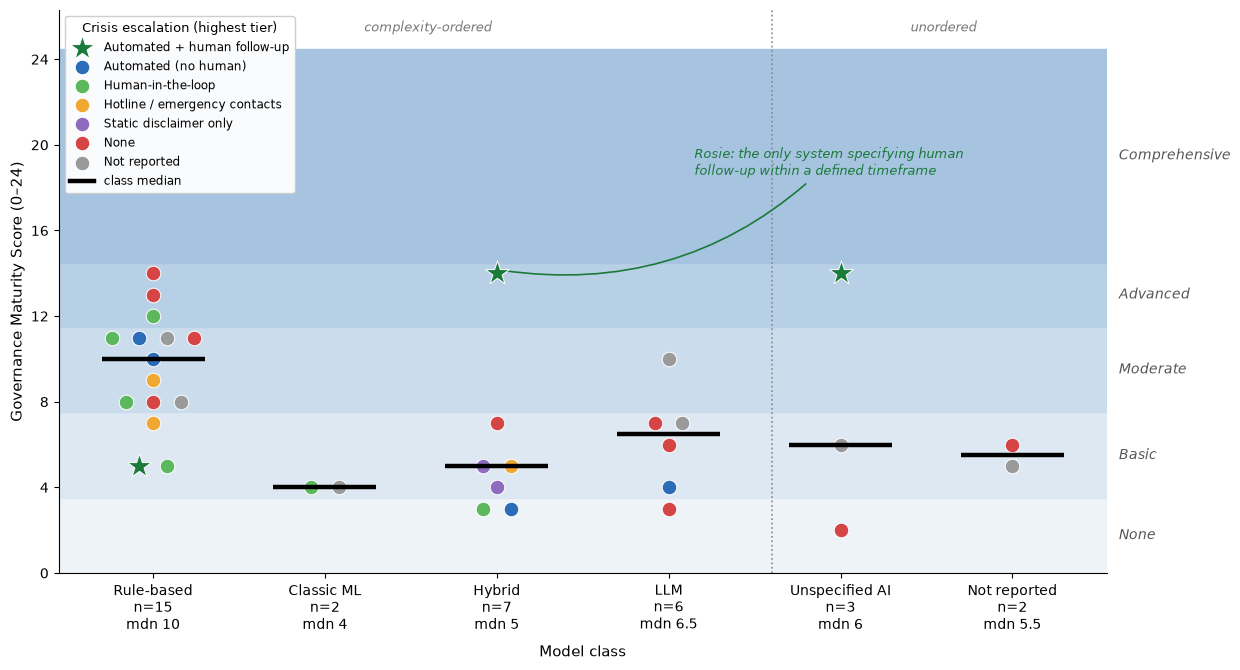

In [13]:
"""
Fig. 5 | Governance maturity by model class and crisis-escalation tier.
"""
TIER_CODE = {
    "Automated detection + human follow-up": "AH",
    "Automated detection (no human)": "AUTO",
    "Human-in-the-loop": "HIL",
    "Hotline / emergency contacts": "HOT",
    "Static disclaimer only": "DISC",
    "None": "NONE",
    "Not reported": "NR",
}
CLASS_ORDER = ["Rule-based", "Classical ML", "Hybrid", "LLM", "Unspecified AI", "Not reported"]
AXIS_LABEL = {"Classical ML": "Classic ML"}

# class -> [(study_id, GMS total, crisis tier code)], in study-ID order
data = {AXIS_LABEL.get(c, c): [(r.study_id, r.gms_total, TIER_CODE[r.crisis_tier])
                                for r in gms[gms.model_class_analytic == c].itertuples()]
        for c in CLASS_ORDER}

tier_style = {
 "AH":  dict(c="#1a7a3a", marker="*", s=330, label="Automated + human follow-up", z=6),
 "AUTO":dict(c="#2b6cb8", marker="o", s=110, label="Automated (no human)",        z=5),
 "HIL": dict(c="#5cb85c", marker="o", s=110, label="Human-in-the-loop",           z=5),
 "HOT": dict(c="#f0a832", marker="o", s=110, label="Hotline / emergency contacts",z=5),
 "DISC":dict(c="#8e6bbf", marker="o", s=110, label="Static disclaimer only",      z=5),
 "NONE":dict(c="#d64545", marker="o", s=110, label="None",                        z=5),
 "NR":  dict(c="#9a9a9a", marker="o", s=110, label="Not reported",                z=5),
}

fig, ax = plt.subplots(figsize=(12.5, 6.8))
bands  = [(0,3.5,"None"),(3.5,7.5,"Basic"),(7.5,11.5,"Moderate"),
          (11.5,14.5,"Advanced"),(14.5,24.5,"Comprehensive")]
shades = ["#eef3f8","#dde8f2","#cbdcec","#b8d0e6","#a6c4e0"]
for (lo,hi,lab),sh in zip(bands,shades):
    ax.axhspan(lo,hi,color=sh,zorder=0)
    ax.text(5.62,(lo+min(hi,24.5))/2,lab,fontsize=10,style="italic",color="#555",va="center")
    
classes=list(data.keys()); seen=set()
for xi,cl in enumerate(classes):
    pts=data[cl]; ys=[p[1] for p in pts]
    cnt=Counter(ys); off={}
    xs=[]
    for s,y,t in pts:
        k=cnt[y]; i=off.get(y,0); off[y]=i+1
        xs.append(xi+(0 if k==1 else (i-(k-1)/2)*0.16))
    for (s,y,t),x in zip(pts,xs):
        st=tier_style[t]
        lab=st["label"] if st["label"] not in seen else None
        seen.add(st["label"])
        ax.scatter(x,y,c=st["c"],marker=st["marker"],s=st["s"],label=lab,
                   zorder=st["z"],edgecolors="white",linewidths=0.7)
    ax.hlines(np.median(ys),xi-0.3,xi+0.3,color="black",lw=3.2,zorder=7)
ax.axvline(3.6,color="#888",ls=":",lw=1.2)
ax.text(1.6,25.3,"complexity-ordered",fontsize=9.5,color="#777",style="italic",ha="center")
ax.text(4.6,25.3,"unordered",fontsize=9.5,color="#777",style="italic",ha="center")
meds={cl:np.median([p[1] for p in data[cl]]) for cl in classes}
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([f"{cl}\nn={len(data[cl])}\nmdn {meds[cl]:g}" for cl in classes],fontsize=10)
ax.set_ylim(0,26.3); ax.set_yticks(range(0,25,4)); ax.set_xlim(-0.55,5.55)
ax.set_ylabel("Governance Maturity Score (0\u201324)",fontsize=11)
ax.set_xlabel("Model class",fontsize=11,labelpad=8)
ax.annotate("Rosie: the only system specifying human\nfollow-up within a defined timeframe",
            xy=(2.02,14.15),xytext=(3.15,18.6),fontsize=9.5,color="#1a7a3a",style="italic",
            arrowprops=dict(arrowstyle="-",color="#1a7a3a",lw=1.2,
                            connectionstyle="arc3,rad=-0.25"))

order=["Automated + human follow-up","Automated (no human)","Human-in-the-loop",
       "Hotline / emergency contacts","Static disclaimer only","None","Not reported"]
handles,labs=ax.get_legend_handles_labels(); hl=dict(zip(labs,handles))
med_h=mlines.Line2D([],[],color="black",lw=3.2,label="class median")
ax.legend([hl[o] for o in order]+[med_h],order+["class median"],loc="upper left",
          fontsize=8.8,title="Crisis escalation (highest tier)",title_fontsize=9.2,framealpha=0.95)

for sp in ["top","right"]: ax.spines[sp].set_visible(False)
plt.tight_layout()
save(fig, "fig5_gms_by_model_class")
plt.show()

## Fig. 6 | Governance Maturity Profile across the six GMS dimensions

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


Dimension means: {'Privacy': 0.89, 'Safety': 1.57, 'Monitoring': 0.46, 'Regulation': 1.23, 'Bias & fairness': 2.0, 'Consent': 1.34}
saved fig6_gms_profile.png / .pdf


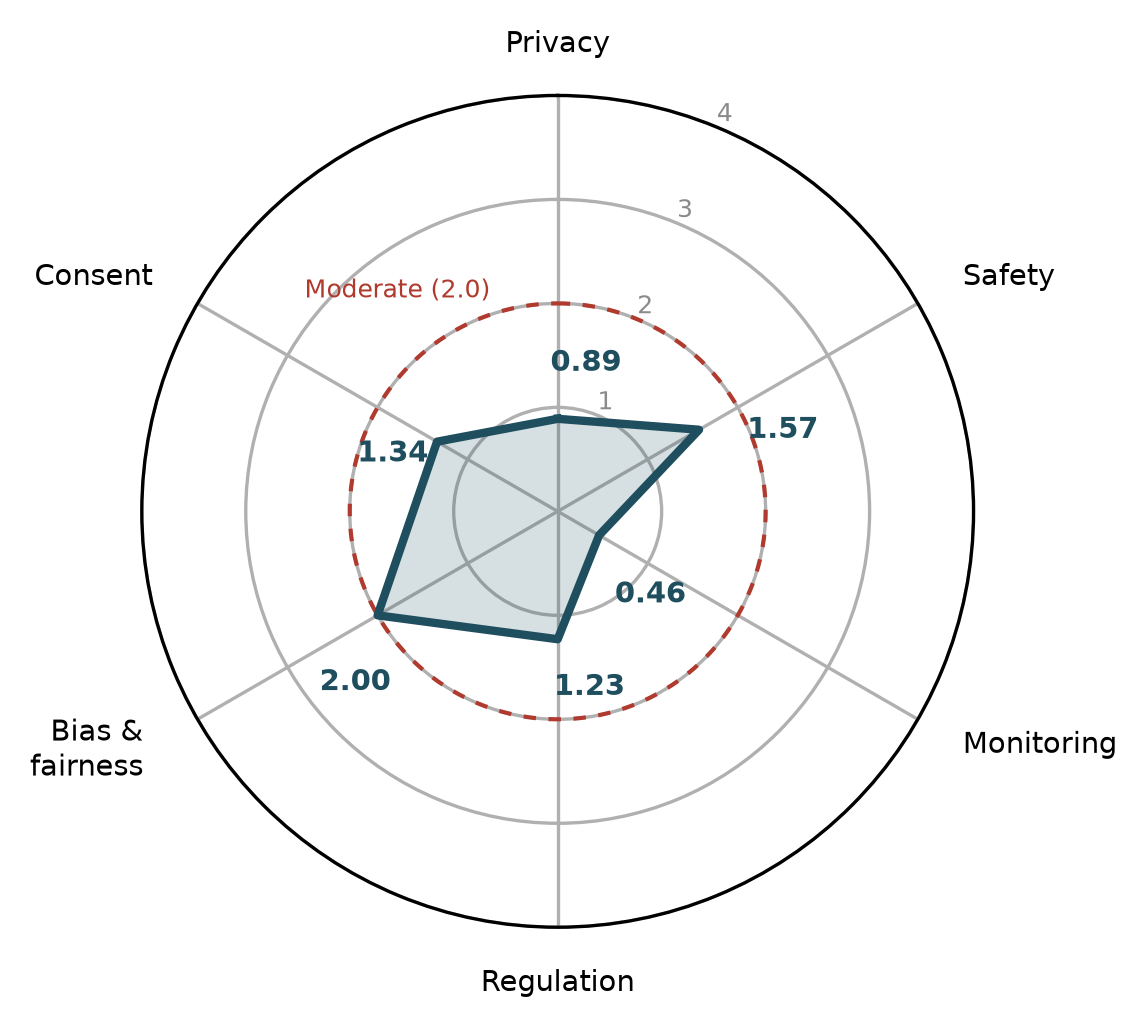

In [14]:
"""
Fig. 6 | Governance Maturity Profile (radar chart).
Mean score per GMS dimension (0-4), across all 35 studies.
"""

# ---- DATA: per-study dimension scores (0-4) ----
DIMS = ["privacy", "safety", "monitoring", "regulation", "bias_fairness", "consent"]
dims = {r.study_id: tuple(getattr(r, d) for d in DIMS) for r in gms.itertuples()}

labels = ["Privacy", "Safety", "Monitoring", "Regulation", "Bias &\nfairness", "Consent"]
means = [round(np.mean([dims[s][d] for s in dims]), 2) for d in range(6)]
print("Dimension means:", dict(zip([l.replace('\n',' ') for l in labels], means)))
assert sum(sum(v) for v in dims.values()) == 262, "grid total mismatch"

N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
vals = means + means[:1]
angles2 = angles + angles[:1]

fig, ax = plt.subplots(figsize=(3.9, 3.9), subplot_kw=dict(polar=True), dpi=300)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_ylim(0, 4)

# radial gridlines/labels UNDER the data; keep the "1" ring tick away from the top vertex
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1", "2", "3", "4"], fontsize=6, color="#8a8a8a")
ax.tick_params(axis='y', pad=0)
ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_axisbelow(True)

# dimension name labels (outside the outer ring)
label_positions = [
    (angles[0], 4.35, "Privacy",          "center", "bottom"),
    (angles[1], 4.5,  "Safety",           "left",   "center"),
    (angles[2], 4.5,  "Monitoring",       "left",   "center"),
    (angles[3], 4.4,  "Regulation",       "center", "top"),
    (angles[4], 4.6,  "Bias &\nfairness", "right",  "center"),
    (angles[5], 4.5,  "Consent",          "right",  "center"),
]
for angle, r, lbl, ha, va in label_positions:
    ax.text(angle, r, lbl, ha=ha, va=va, fontsize=7, fontweight="medium")

# Moderate threshold ring FIRST (so value labels sit on top of it)
theta_ring = np.linspace(0, 2 * np.pi, 200)
ax.plot(theta_ring, [2.0] * 200, linestyle=(0, (3, 3)), color="#B03A2E", linewidth=1, zorder=3)
ax.text(np.deg2rad(324), 2.62, "Moderate (2.0)", color="#B03A2E", fontsize=6, ha="center", va="center", zorder=4)

# profile polygon
ax.plot(angles2, vals, color="#1F4E5F", linewidth=2, zorder=5)
ax.fill(angles2, vals, color="#1F4E5F", alpha=0.18, zorder=2)

# value labels: nudged into the empty wedge BETWEEN spokes (angular offset) and set
# just outside each vertex, so no label overlaps a spoke, ring, or the profile line.
# No halo is used, so every gridline stays fully continuous.
half = np.pi / N                      # half the angular gap between adjacent spokes
# Each label: angular shift into the empty wedge (off the spokes) + a hand-tuned
# radius that avoids the 1/2/3 ring circles. No halo, so gridlines stay continuous.
place = [  # (angular shift, radius)
    ( +0.36*half, 1.45),   # Privacy    (0.91) -> between rings 1 and 2
    ( +0.34*half, 2.30),   # Safety     (1.56) -> outside ring 2
    ( +0.40*half, 1.20),   # Monitoring (0.47) -> between rings 1 and 2, off the spoke
    ( -0.34*half, 1.72),   # Regulation (1.21) -> between rings 1 and 2
    ( -0.34*half, 2.55),   # Bias&fair  (1.97) -> outside ring 2
    ( -0.36*half, 1.68),   # Consent    (1.38) -> between rings 1 and 2
]
for a, v, (sh, r) in zip(angles, means, place):
    ax.text(a + sh, r, f"{v:.2f}", ha="center", va="center",
            fontsize=7, color="#1F4E5F", fontweight="bold", zorder=6)

plt.tight_layout()
save(fig, "fig6_gms_profile")
plt.show()

## Fig. 7 | Governance reporting by model class

saved fig7_governance_reporting.png / .pdf


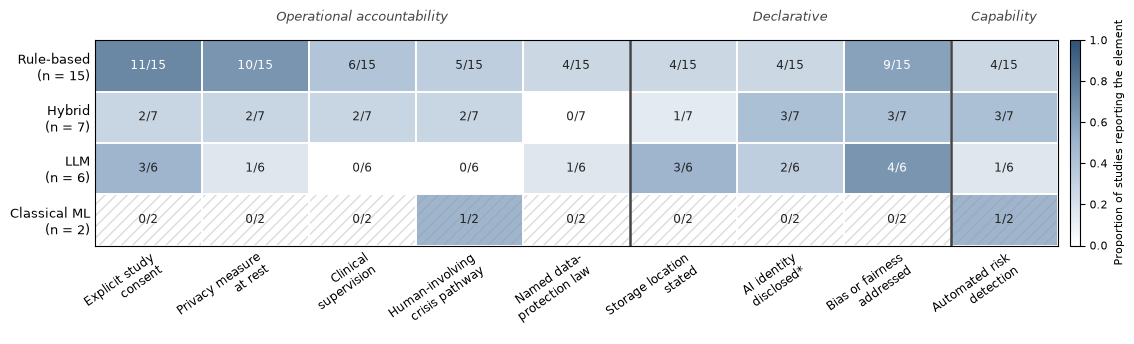

In [15]:
"""
Fig. 7 | Governance reporting by model class.
"""

# --------------------------------------------------------------------- data
# element key -> (display label, block)
ELEMENTS = [
    ("explicit_consent",     "Explicit study\nconsent",          "Operational accountability"),
    ("privacy_at_rest",      "Privacy measure\nat rest",         "Operational accountability"),
    ("clinical_supervision", "Clinical\nsupervision",            "Operational accountability"),
    ("human_crisis_pathway", "Human-involving\ncrisis pathway",  "Operational accountability"),
    ("named_regulation",     "Named data-\nprotection law",      "Operational accountability"),
    ("storage_location",     "Storage location\nstated",         "Declarative"),
    ("ai_identity",          "AI identity\ndisclosed*",          "Declarative"),
    ("bias_fairness",        "Bias or fairness\naddressed",      "Declarative"),
    ("automated_detection",  "Automated risk\ndetection",        "Capability"),
]
CLASSES = ["Rule-based", "Hybrid", "LLM", "Classical ML"]

merged = elements.merge(gms[["study_id", "model_class_analytic"]], on="study_id")
denominators = np.array([(merged.model_class_analytic == c).sum() for c in CLASSES])
counts = np.array([[merged.loc[merged.model_class_analytic == c, k].sum()
                    for k, _, _ in ELEMENTS] for c in CLASSES])

proportions = counts / denominators[:, None]
labels = [lab for _, lab, _ in ELEMENTS]
blocks = [b for _, _, b in ELEMENTS]

# ------------------------------------------------------------------ heatmap
# Sequential single hue: white = not reported, dark = reported.
# Viridis is avoided because its zero end is dark and reads as "high".
cmap = LinearSegmentedColormap.from_list("gov", ["#FFFFFF", "#9FB6CE", "#2F5375"])

fig, ax = plt.subplots(figsize=(11.5, 3.6))
im = ax.imshow(proportions, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right",
                   rotation_mode="anchor", fontsize=8.4)
ax.set_yticks(np.arange(len(CLASSES)))
ax.set_yticklabels([f"{c}\n(n = {n})" for c, n in zip(CLASSES, denominators)],
                   fontsize=9)

# cell labels: contrast follows the cell value, not a fixed colour
for i in range(len(CLASSES)):
    for j in range(len(labels)):
        ax.text(j, i, f"{counts[i, j]}/{denominators[i]}",
                ha="center", va="center", fontsize=8.6,
                color="white" if proportions[i, j] > 0.5 else "#222222")

# block dividers and headings
x = -0.5
for name in ("Operational accountability", "Declarative", "Capability"):
    w = blocks.count(name)
    if x > -0.5:
        ax.axvline(x, color="#444444", lw=1.8)
    ax.text(x + w / 2, -0.82, name, ha="center", va="bottom",
            fontsize=9, style="italic", color="#444444")
    x += w

# white gridlines
ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(CLASSES), 1), minor=True)
ax.grid(which="minor", color="white", lw=1.4)
ax.tick_params(which="minor", length=0)
ax.tick_params(axis="both", which="major", length=0)

# flag the underpowered row: n = 2 makes proportions uninformative
ax.add_patch(plt.Rectangle((-0.5, len(CLASSES) - 1.5), len(labels), 1,
                           fill=False, hatch="///", edgecolor="#999999",
                           lw=0, alpha=0.35))

cbar = fig.colorbar(im, ax=ax, fraction=0.016, pad=0.012)
cbar.set_label("Proportion of studies reporting the element", fontsize=8.2)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.ax.tick_params(labelsize=7.6)

plt.tight_layout()
save(fig, "fig7_governance_reporting", dpi=600)
plt.show()